<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h1>Breast Cancer modeling</h1>
</div>

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>This notebook :</h2>
    <p>
    - Loads processed data<br>
    - Trains classification models and evaluates their performances<br>
    <ul>
        <li>baseline `DummyClassifier`</li>
        <li>Home made Perceptron</li>
    </ul>
    - evaluation<br>
    - performance analysis<br>
    - Saves models into `models...  NOT YET`<br>
    </p>
</div>

In [1]:
import pandas as pd
from sklearn.dummy import DummyClassifier

from building_perceptron.config import PROCESSED_DATA_DIR
from building_perceptron.model_utils import evaluate_classification, Perceptron

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>Import the source files with the proper encoding</h2>
</div>

In [2]:
X_train_path = PROCESSED_DATA_DIR / "X_train_scaled.csv"
y_train_path = PROCESSED_DATA_DIR / "y_train.csv"
X_test_path = PROCESSED_DATA_DIR / "X_test_scaled.csv"
y_test_path = PROCESSED_DATA_DIR / "y_test.csv"

X_train = pd.read_csv(X_train_path, encoding="ascii")
y_train = pd.read_csv(y_train_path, encoding="ascii").squeeze("columns")

X_test = pd.read_csv(X_test_path, encoding="ascii")
y_test = pd.read_csv(y_test_path, encoding="ascii").squeeze("columns")

In [3]:
print(f"\
    X_train type: {type(X_train)}\n\
    X_train shape : {X_train.shape}\n\
    \n\
    y_train type : {type(y_train)}\n\
    y_train shape : {y_train.shape}\n\
    \n\
    X_test type: {type(X_test)}\n\
    X_test shape: {X_test.shape}\n\
    \n\
    y_test type: {type(y_test)}\n\
    y_test shape: {y_test.shape}"
    )

    X_train type: <class 'pandas.DataFrame'>
    X_train shape : (455, 20)
    
    y_train type : <class 'pandas.Series'>
    y_train shape : (455,)
    
    X_test type: <class 'pandas.DataFrame'>
    X_test shape: (114, 20)
    
    y_test type: <class 'pandas.Series'>
    y_test shape: (114,)


<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Modèle de base : DummyCLassifier</h3>
</div>

=== Classification : DummyClassifier ===
Meilleurs paramètres : {'strategy': 'most_frequent'}
Accuracy : 0.6316

Rapport de classification :
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        72
           1       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



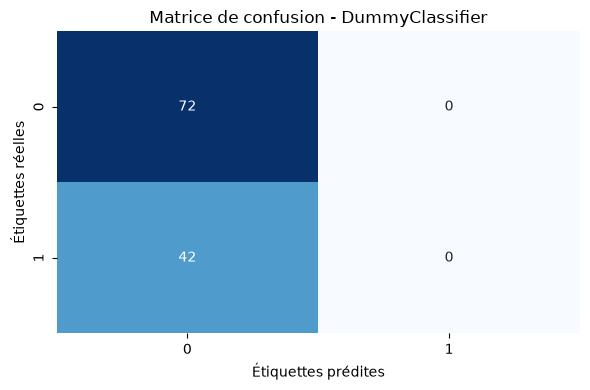

In [4]:
dummy = DummyClassifier()

param_grid_dummy = {'strategy': ['most_frequent', 'prior','stratified', 'uniform']}

results_dc = evaluate_classification(dummy, param_grid_dummy, X_train, y_train, X_test, y_test)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8;" >
<hp style="margin: auto; padding: 20px ">
Accuracy (0.6316) :<br>
Dans le jeu de test, il y a environ 63% de tumeurs bénignes. Si l'on prédis "bénin" au hasard pour tout le monde, on a raison 63% du temps.<br>

Recall de la classe 1 (0.00) :<br>
Le modèle a raté 100% des tumeurs malignes (classe 1)<br>

F1-score de la classe 1 (0.00) :<br>
Le modele n'a trouvé aucun cas positif, son score d'efficacité pour la maladie est nul.
Preprocessing UNIQUEMENT sur les features d'entraînement</p>
</div>

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Perceptron</h3>
</div>

=== Classification : Perceptron ===
Meilleurs paramètres : {'learning_rate': 0.1, 'n_iterations': 100}
Accuracy : 0.9386

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



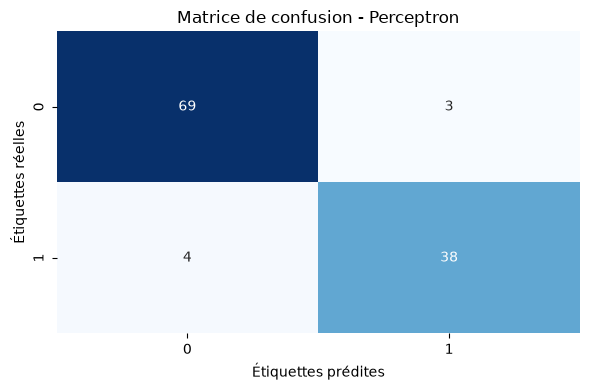

In [6]:
# On définit une grille de paramètres simple pour le Perceptron (la fonction en attend une)
param_grid = {'n_iterations': [100, 500], 'learning_rate': [0.1, 0.01]}

results_percep = evaluate_classification(
    Perceptron(activation="step"),
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test
)

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Another try with a sigmomidal activation function</h3>
</div>

=== Classification : Perceptron ===
Meilleurs paramètres : {'learning_rate': 0.001, 'n_iterations': 100, 'threshold': 0.5}
Accuracy : 0.9386

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



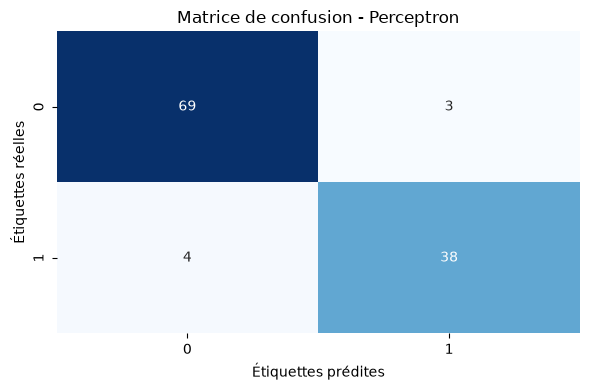

In [7]:
param_grid = {"learning_rate": [0.001, 0.01, 0.1], "n_iterations": [50, 100, 200], "threshold": [0.3, 0.5, 0.7]}

results_percep = evaluate_classification(
    Perceptron(activation="sigmoid"),
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
)

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Analyse des performances</h3>

Comparaison avec la Baseline :<br>
Le Perceptron (95,61%) écrase littéralement le DummyClassifier (63,16%)

Cela prouve que le modèle a réellement appris des relations mathématiques dans les données et ne prédit pas au hasard.

Équilibre des classes : Les scores (F1-score) sont excellents pour la classe 0 (0.97) comme pour la classe 1 (0.94).<br>
Le modèle n'est pas "paresseux" et arrive à distinguer les deux types de tumeurs.

<h3>Recall classe 1</h3>
Le rappel pour les tumeurs malignes est de 0.93<br>
Cela signifie que sur 42 cas réels de cancer dans le jeu de test, le modèle en a détecté environ 39.<br>
<strong>Il en a raté 3 (Faux Négatifs)</strong>
</p>

<h4>Conclusion sur l'efficacité</h4>
Le Perceptron s'avère extrêmement efficace pour cette problématique de santé.<br>
Avec une précision globale de 95,61 %<br>
il démontre que les caractéristiques morphologiques des cellules (rayon, symétrie, concavité)<br>
permettent de séparer les classes de manière quasi-linéaire.<br>
Cependant, dans un contexte médical, <strong>le taux de faux négatifs (7% des cas malins non détectés) reste un point de vigilance qui nécessiterait un ajustement du modèle.</strong>

<h4>Pistes d'amélioration proposées (Sans les implémenter)</h4>

**Changement de fonction d'activation :**<br>
Remplacer la fonction "seuil" (Heaviside Step Function) par une fonction Sigmoïde<br>
pour transformer le Perceptron en Régression Logistique.<br>
Cela permettrait d'obtenir une probabilité (ex: "80% de risque") plutôt qu'une réponse binaire, facilitant le diagnostic médical.

**Optimisation du Recall :**<br>
Modifier le seuil de décision (actuellement à 0.5) pour le descendre à 0.3.<br>
Cela augmenterait les faux positifs mais réduirait drastiquement les faux négatifs (on préfère s'inquiéter pour rien que de rater un cancer).

**Utilisation de modèles non-linéaires :**<br>
Tester un SVM (Support Vector Machine) avec un noyau RBF ou un Random Forest pour capturer des relations plus complexes entre les variables que le Perceptron ne peut pas voir à cause de sa nature linéaire.

**Faire du multicouche** la backpropagation permetrait d'ajuster les poids et d'améliorer la prédiction.

</div>